In [1]:
install.packages("ggpubr")

also installing the dependencies ‘numDeriv’, ‘SparseM’, ‘MatrixModels’, ‘backports’, ‘carData’, ‘nnet’, ‘pbkrtest’, ‘quantreg’, ‘broom’, ‘corrplot’, ‘car’, ‘ggsci’, ‘ggsignif’, ‘polynom’, ‘rstatix’




In [80]:
install.packages("extrafont")

also installing the dependencies ‘extrafontdb’, ‘Rttf2pt1’




In [91]:
# Load libraries
library("ggpubr")
suppressMessages(library(lme4))
suppressMessages(library(data.table))
suppressMessages(require("Matrix"))
library("reticulate")
library(ggplot2)

# Use the path to your Python executable in the virtual environment
use_python("/lila/home/forsythb/.virtualenvs/r-reticulate/bin/")

# Look at where Python is located
py_config()

# Import scanpy
sc <- import("scanpy")

python:         /lila/home/forsythb/.virtualenvs/r-reticulate/bin/python
libpython:      /home/forsythb/anaconda3/lib/libpython3.8.so
pythonhome:     /lila/home/forsythb/.virtualenvs/r-reticulate:/lila/home/forsythb/.virtualenvs/r-reticulate
version:        3.8.18 (default, Sep 11 2023, 13:40:15)  [GCC 11.2.0]
numpy:          /lila/home/forsythb/.virtualenvs/r-reticulate/lib/python3.8/site-packages/numpy
numpy_version:  1.24.4

NOTE: Python version was forced by use_python() function

In [24]:
# Read in the adata
adata <- sc$read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/postprocess_adata/adata.combined.postprocess.leiden.h5ad')

In [42]:
# MAST CLUSTER 10, LEIDEN 0.25
deg_df_10 = read.table("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/mast_25/leiden_res_.25_10.csv", header=T, sep=',')

In [26]:
# Calculate the mean expression value
counts <- t(adata$X)
# Calculate the base mean
base_mean <- rowMeans(counts)
deg_df_10$baseMean <- base_mean

In [48]:
# Calculate the mean expression value
counts <- t(adata$X)

# Calculate the base mean
base_mean <- rowMeans(counts)

# Calculate the log2 of baseMean
deg_df_10$baseMeanLog2 <- log2(base_mean)

In [49]:
# Rename columns in the df
colnames(deg_df_10)[colnames(deg_df_10) == "coef"] <- "log2FoldChange"
colnames(deg_df_10)[colnames(deg_df_10) == "fdr"] <- "padj"

In [50]:
deg_df_10

X,primerid,Pr..Chisq.,log2FoldChange,ci.hi,ci.lo,padj,log2BaseMean,baseMeanLog2
<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,AC008591.1,0,0.3944979,0.4227402,0.3662556,0,-9.6756231,-9.6756231
2,AC009975.1,0,0.3262521,0.3541188,0.2983855,0,-11.2694558,-11.2694558
3,AC099520.1,0,1.8447013,1.8789027,1.8105000,0,-0.7777674,-0.7777674
4,ADAMTS19,0,1.3783231,1.4010465,1.3555997,0,-9.3909107,-9.3909107
5,AGR2,0,-0.3950805,-0.3611926,-0.4289684,0,-9.5202982,-9.5202982
6,AL022068.1,0,0.9595661,0.9915800,0.9275523,0,-10.1305302,-10.1305302
7,AREG,0,0.6804025,0.7048542,0.6559507,0,-9.0027834,-9.0027834
8,ARHGEF2,0,0.5506384,0.5809782,0.5202987,0,-16.2192675,-16.2192675
9,ATP5F1D,0,0.4365904,0.4537056,0.4194753,0,-9.6403827,-9.6403827


Warning message:
“Removed 9256 rows containing missing values (`geom_point()`).”


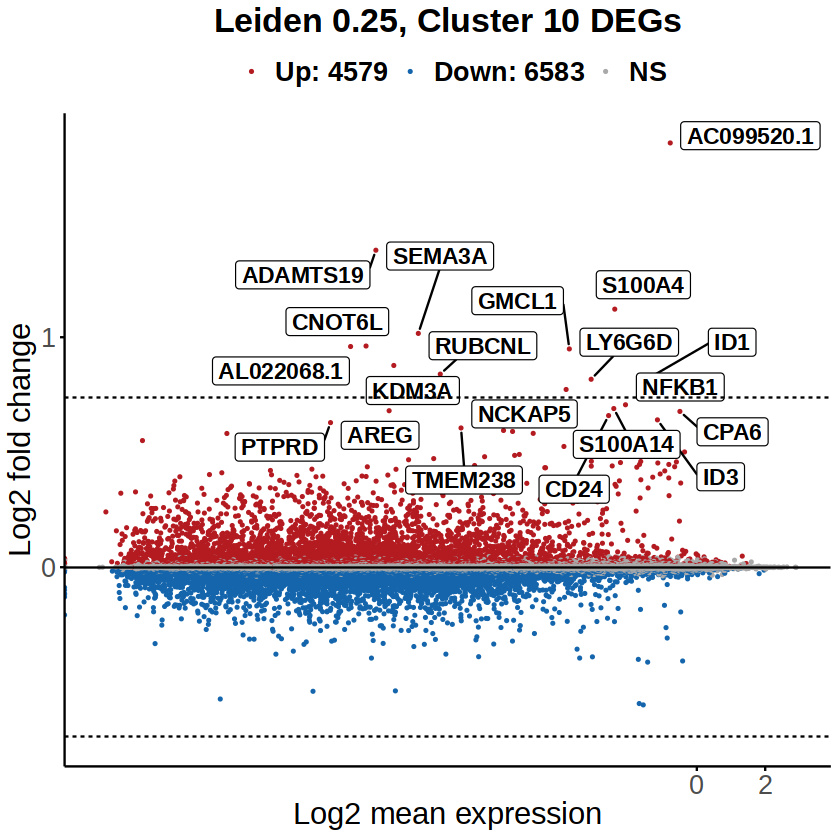

In [93]:
# Default plot
ggmaplot <- ggmaplot(deg_df_10,
                     fdr = 0.05, fc = 0.6, size = 0.4,
                     palette = c("#B31B21", "#1465AC", "darkgray"),
                     genenames = as.vector(deg_df_10$primerid),
                     legend = "top", top = 20,
                     select.top.method = c("fc"),
                     font.label = c("bold", 14), label.rectangle = TRUE,
                     font.legend = "bold",
                     font.main = "bold") +
             theme(axis.text = element_text(size = 16),  # Change size of axis labels
                   axis.title = element_text(size = 18), # Change size of axis titles
                   legend.text = element_text(size = 16), # Change size of legend text
                   plot.title = element_text(hjust = 0.5, size = 20, face = "bold")) + # Add plot title
             labs(title = "Leiden 0.25, Cluster 10 DEGs")

# Print the ggmaplot
print(ggmaplot)

In [59]:
# MAST CLUSTER 9, LEIDEN 0.25
deg_df_9 = read.table("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/mast_25/leiden_res_.25_9.csv", header=T, sep=',')

In [64]:
# Rename columns in the df
colnames(deg_df_9)[colnames(deg_df_9) == "coef"] <- "log2FoldChange"
colnames(deg_df_9)[colnames(deg_df_9) == "fdr"] <- "padj"
deg_df_9$baseMeanLog2 <- log2(base_mean)

Warning message:
“Removed 8602 rows containing missing values (`geom_point()`).”


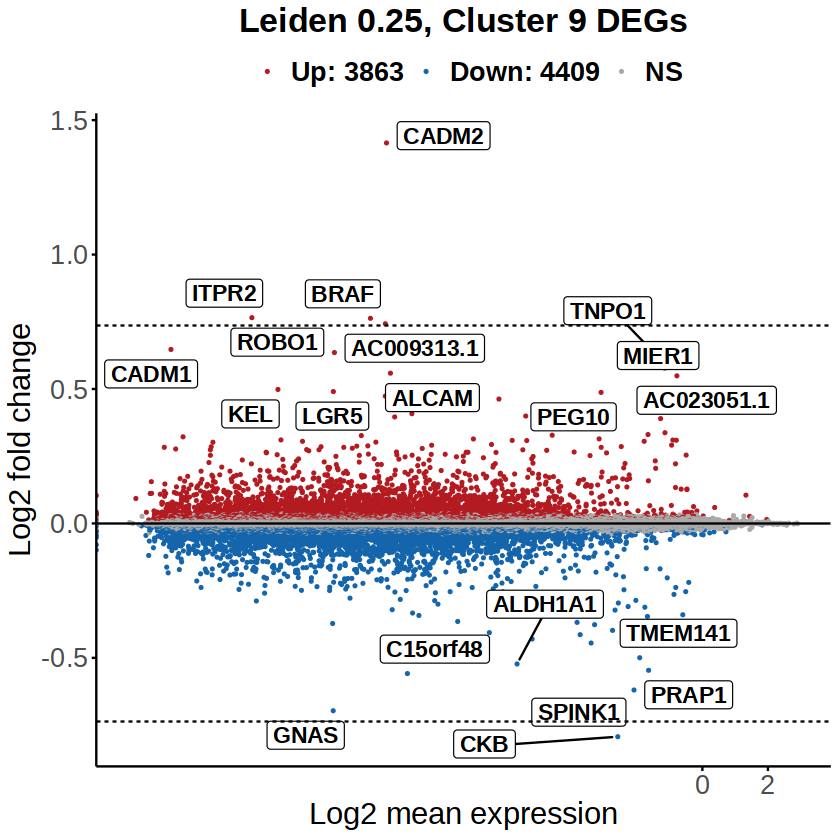

In [92]:
ggmaplot <- ggmaplot(deg_df_9,
                     fdr = 0.05, fc = 0.6, size = 0.4,
                     palette = c("#B31B21", "#1465AC", "darkgray"),
                     genenames = as.vector(deg_df_9$primerid),
                     legend = "top", top = 20,
                     select.top.method = c("fc"),
                     font.label = c("bold", 14), label.rectangle = TRUE,
                     font.legend = "bold",
                     font.main = "bold") +
             theme(axis.text = element_text(size = 16),  # Change size of axis labels
                   axis.title = element_text(size = 18), # Change size of axis titles
                   legend.text = element_text(size = 16), # Change size of legend text
                   plot.title = element_text(hjust = 0.5, size = 20, face = "bold")) + # Add plot title
             labs(title = "Leiden 0.25, Cluster 9 DEGs")  # Specify the plot title

# Print the ggmaplot
print(ggmaplot)

In [66]:
# MAST CLUSTER 5, LEIDEN 0.25
deg_df_5 = read.table("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/mast_25/leiden_res_.25_5.csv", header=T, sep=',')

In [67]:
# Rename columns in the df
colnames(deg_df_5)[colnames(deg_df_5) == "coef"] <- "log2FoldChange"
colnames(deg_df_5)[colnames(deg_df_5) == "fdr"] <- "padj"
deg_df_5$baseMeanLog2 <- log2(base_mean)

Warning message:
“Removed 6841 rows containing missing values (`geom_point()`).”


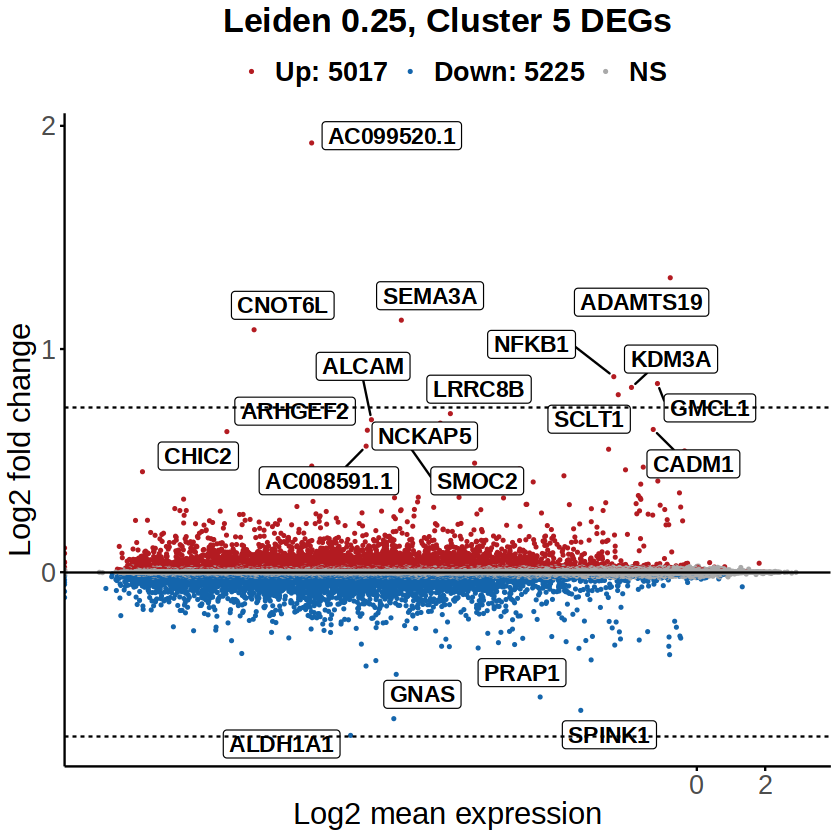

In [94]:
ggmaplot <- ggmaplot(deg_df_5,
                     fdr = 0.05, fc = 0.6, size = 0.4,
                     palette = c("#B31B21", "#1465AC", "darkgray"),
                     genenames = as.vector(deg_df_5$primerid),
                     legend = "top", top = 20,
                     select.top.method = c("fc"),
                     font.label = c("bold", 14), label.rectangle = TRUE,
                     font.legend = "bold",
                     font.main = "bold") +
             theme(axis.text = element_text(size = 16),  # Change size of axis labels
                   axis.title = element_text(size = 18), # Change size of axis titles
                   legend.text = element_text(size = 16), # Change size of legend text
                   plot.title = element_text(hjust = 0.5, size = 20, face = "bold")) + # Add plot title
             labs(title = "Leiden 0.25, Cluster 5 DEGs")  # Specify the plot title

# Print the ggmaplot
print(ggmaplot)

In [74]:
# MAST CLUSTER 0, LEIDEN 0.1
deg_df_0 = read.table("/data/chanjlab/CRC_ZFP36L2.092023/Organoid/output_new/mast/leiden_res_0.1_0.csv", header=T, sep=',')

In [75]:
# Rename columns in the df
colnames(deg_df_0)[colnames(deg_df_0) == "coef"] <- "log2FoldChange"
colnames(deg_df_0)[colnames(deg_df_0) == "fdr"] <- "padj"
deg_df_0$baseMeanLog2 <- log2(base_mean)

Warning message:
“Removed 3465 rows containing missing values (`geom_point()`).”


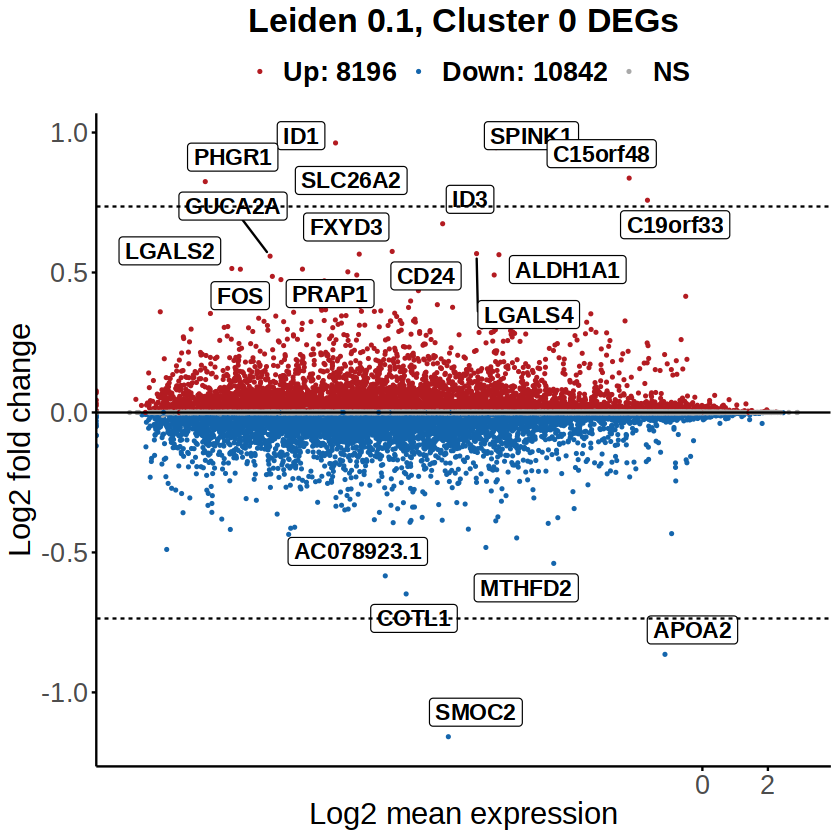

In [95]:
# Default plot
ggmaplot <- ggmaplot(deg_df_0,
                     fdr = 0.05, fc = 0.6, size = 0.4,
                     palette = c("#B31B21", "#1465AC", "darkgray"),
                     genenames = as.vector(deg_df_0$primerid),
                     legend = "top", top = 20,
                     select.top.method = c("fc"),
                     font.label = c("bold", 14), label.rectangle = TRUE,
                     font.legend = "bold",
                     font.main = "bold") +
             theme(axis.text = element_text(size = 16),  # Change size of axis labels
                   axis.title = element_text(size = 18), # Change size of axis titles
                   legend.text = element_text(size = 16), # Change size of legend text
                   plot.title = element_text(hjust = 0.5, size = 20, face = "bold")) + # Add plot title
             labs(title = "Leiden 0.1, Cluster 0 DEGs")  # Specify the plot title

# Print the ggmaplot
print(ggmaplot)